# correlation check, feature removal, rdkit and maccs
## using log t1/2
2025-11-05, Alexander Minidis

2025-11-13 Bayesian test

### Air data, ok models

In [1]:
import sys
from pathlib import Path

notebookdir = Path.cwd().parents[2]
sys.path.append(str(notebookdir))  # this way we can import src modules even in different subfolders
from typing import Any
import pandas as pd
import numpy as np

import sqlalchemy as sa
from sqlalchemy.orm import sessionmaker
from src.db_utils import get_selected_data
from src.rdkit_tools import MACCS_NAMES
from src.legacy.ml_tools import decorrelate, drop_irrelevant_columns

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, explained_variance_score, mean_absolute_error, root_mean_squared_error
import xgboost as xgb

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 250)
%matplotlib inline

In [2]:
# set directories and filenames, load database
working_dir = Path.cwd().parents[2]
data_dir = working_dir / "processed_data"
database_file = data_dir / "hsbd_t_half_all.db"
engine = sa.create_engine(f"sqlite:///{database_file}")
Session = sessionmaker(bind=engine)

In [3]:
# get all data
air_data = get_selected_data("air", Session)
soil_data = get_selected_data("soil", Session)
water_data = get_selected_data("water", Session)
sediment_data = get_selected_data("sediment", Session)

air_data = drop_irrelevant_columns(air_data, to_drop=["None"])
water_data = drop_irrelevant_columns(water_data, to_drop=["None"])
soil_data = drop_irrelevant_columns(soil_data, to_drop=["None"])
sediment_data = drop_irrelevant_columns(sediment_data, to_drop=["None"])

target_column = "T_half_days"

data_to_use = air_data.copy()

## Preprocessing

In [4]:
# we will only use air data
X, y = data_to_use.drop(columns=[target_column]), data_to_use[target_column]
print(f"Number of features: {X.shape[1]}, number of samples: {X.shape[0]}")

Number of features: 370, number of samples: 309


### 1. Outlier detection

REMOVED ! 

### 2. Scaling/normalization

In [5]:
# scaling
scaler = StandardScaler()
# X_scaled without MACCS
X_MACCS = pd.DataFrame(X[MACCS_NAMES])
X_rdkit = pd.DataFrame(X.drop(columns=MACCS_NAMES))
X_scaled = pd.DataFrame(scaler.fit_transform(X_rdkit), columns=X_rdkit.columns)
X_scaled = X_scaled.reset_index(drop=True)
X_MACCS = X_MACCS.reset_index(drop=True)
X_scaled = pd.concat([X_scaled, X_MACCS], axis=1)

In [6]:
# remove zero std columns (no variance)
zero_std_cols = X_scaled.columns[X_scaled.std() == 0]
X_scaled = X_scaled.drop(columns=zero_std_cols)
print(f"Number of features: {X_scaled.shape[1]}, number of samples: {X_scaled.shape[0]}")

Number of features: 304, number of samples: 309


In [7]:
# drop columns hihgly correlated to some others
cols_to_drop = decorrelate(X_scaled, target_column, threshold=0.95)
X_decorrelated = X_scaled.drop(columns=cols_to_drop)
print(f"Number of features: {X_decorrelated.shape[1]}, number of samples: {X_decorrelated.shape[0]}")

Number of features: 250, number of samples: 309


## Model

In [8]:
def output_metrics(y_true: Any, y_pred: Any) -> None:
    print(f"R2: {r2_score(y_true, y_pred):.3f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.3f}")
    print(f"MSE: {mean_squared_error(y_true, y_pred):.3f}")
    print(f"RMSE: {root_mean_squared_error(y_true, y_pred):.3f}")
    print(f"Explained Variance: {explained_variance_score(y_true, y_pred):.3f}")

In [9]:
X = X_decorrelated.copy()
y = np.log10(y)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Bayesian

In [11]:
# Bayesian Ridge Regression with GridSearchCV
param_grid = {
    "alpha_1": [1e-6, 1e-5, 1e-4, 1e-3],
    "alpha_2": [1e-6, 1e-5, 1e-4, 1e-3],
    "lambda_1": [1e-6, 1e-5, 1e-4, 1e-3],
    "lambda_2": [1e-6, 1e-5, 1e-4, 1e-3],
}

bayes_reg = BayesianRidge()
grid_search = GridSearchCV(bayes_reg, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'alpha_1': 1e-06, 'alpha_2': 0.001, 'lambda_1': 0.001, 'lambda_2': 1e-06}


R2: 0.236
MAE: 17.024
MSE: 6097.745
RMSE: 78.088
Explained Variance: 0.240


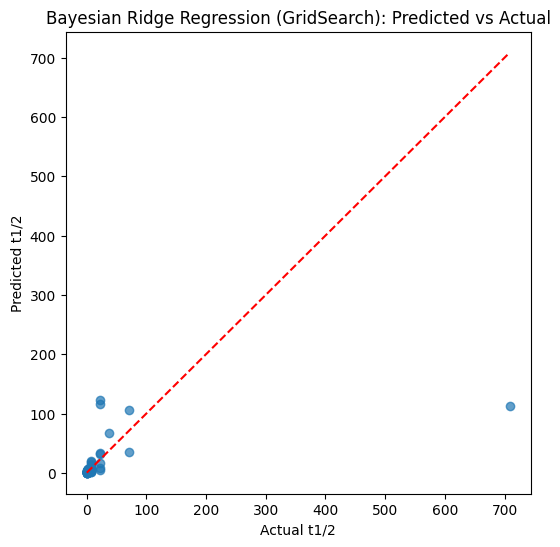

In [12]:
y_pred = grid_search.predict(X_test)

y_test_exp_bayes = np.power(10, y_test)
y_pred_exp_bayes = np.power(10, y_pred)
output_metrics(y_test_exp_bayes, y_pred_exp_bayes)

# Optional: plot predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test_exp_bayes, y_pred_exp_bayes, alpha=0.7)
plt.xlabel("Actual t1/2")
plt.ylabel("Predicted t1/2")
plt.title("Bayesian Ridge Regression (GridSearch): Predicted vs Actual")
plt.plot([y_test_exp_bayes.min(), y_test_exp_bayes.max()], [y_test_exp_bayes.min(), y_test_exp_bayes.max()], "r--")
plt.show()

Top 10 features (by absolute coefficient):
fr_aldehyde: 0.1227)
BCUT2D_MRLOW: 0.1189)
fr_ketone: 0.1017)
fr_Ar_N: 0.0949)
fr_allylic_oxid: 0.0936)
MinEStateIndex: 0.0920)
SlogP_VSA7: 0.0919)
NumSaturatedCarbocycles: 0.0902)
SMR_VSA10: 0.0871)
MACCS_099: 0.0868)


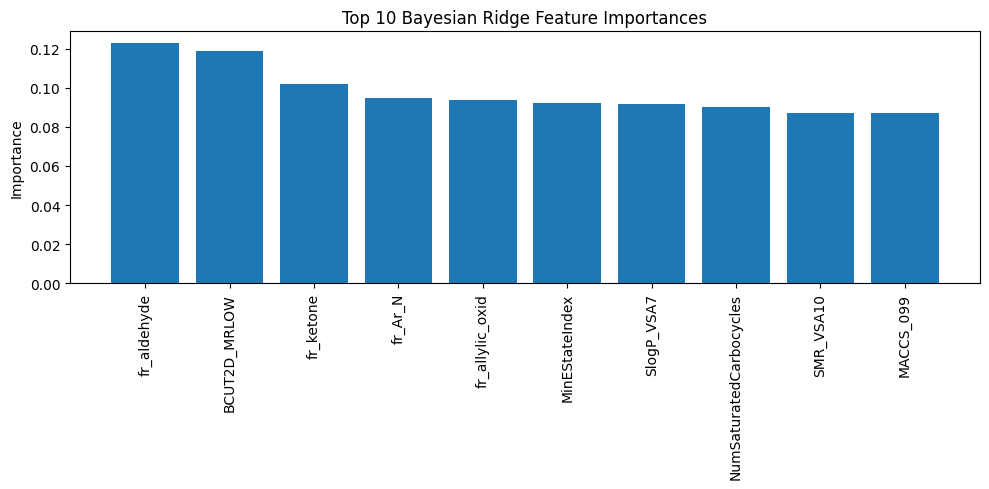

In [13]:
# Extract top 10 features by absolute coefficient value from Bayesian Ridge
importances_bayes = np.abs(grid_search.best_estimator_.coef_)
feature_names = X_train.columns if hasattr(X_train, "columns") else [f"feat_{i}" for i in range(X_train.shape[1])]
top_idx = np.argsort(importances_bayes)[-10:][::-1]
top_features = [(feature_names[i], importances_bayes[i]) for i in top_idx]
print("Top 10 features (by absolute coefficient):")
for name, val in top_features:
    print(f"{name}: {val:.4f})")

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances_bayes[top_idx])
plt.xticks(range(10), X_train.columns[top_idx], rotation=90)
plt.title("Top 10 Bayesian Ridge Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

XGBOOST

In [14]:
# print(np.any(np.isnan(X_train)), np.any(np.isnan(y_train)))
# print(np.any(np.isinf(X_train)), np.any(np.isinf(y_train)))
# X_train = X_train.replace([np.inf, -np.inf], np.nan).dropna()
# y_train = y_train[~X_train.isnull().any(axis=1)]
# X_train = X_train.dropna()

In [15]:
# XGBOOST with GridSearchCV for hyperparameter tuning

xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
param_grid = {
    "n_estimators": [100, 300, 500, 1000],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.1, 0.3],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.7, 1.0],
}
# Use negative root mean squared error as scoring (available in sklearn 1.7.0)
grid_search_xgb = GridSearchCV(
    xgb_model, param_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=2, error_score="raise"
)
grid_search_xgb.fit(X_train, y_train)
print("Best XGBoost parameters:", grid_search_xgb.best_params_)

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best XGBoost parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 1000, 'subsample': 0.7}


R2: 0.540
MAE: 12.131
MSE: 3674.144
RMSE: 60.615
Explained Variance: 0.544


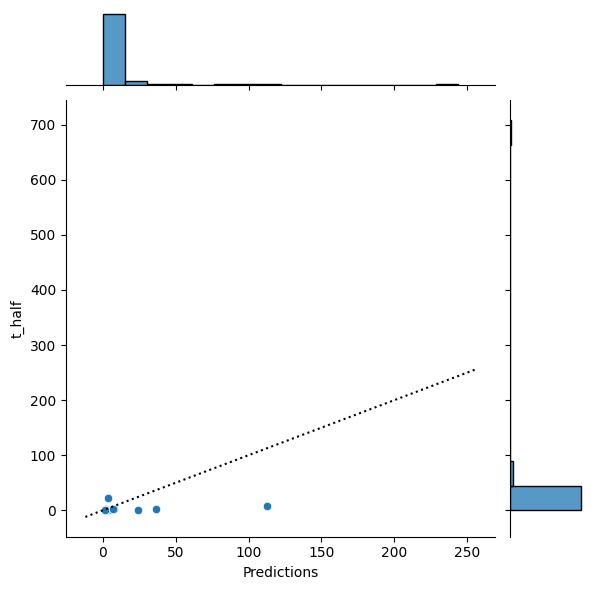

In [16]:
# Predict and evaluate XGBoost with best parameters from GridSearchCV
y_pred = grid_search_xgb.predict(X_test)
y_test_xgboost = np.power(10, y_test)
y_pred_xgboost = np.power(10, y_pred)
output_metrics(y_test_xgboost, y_pred_xgboost)
data = pd.concat([pd.Series(y_pred_xgboost), pd.Series(y_test_xgboost)], axis=1)
data.columns = ["Predictions", "t_half"]

g = sns.jointplot(x="Predictions", y="t_half", data=data)
x0, x1 = g.ax_joint.get_xlim()
y0, y1 = g.ax_joint.get_ylim()
lims = [max(x0, y0), min(x1, y1)]
g.ax_joint.plot(lims, lims, ":k")

Top 10 XGBoost features (by importance):
MACCS_103: 0.1643
SMR_VSA10: 0.0612
BCUT2D_MWHI: 0.0377
NumHAcceptors: 0.0338
EState_VSA9: 0.0246
SlogP_VSA7: 0.0187
MACCS_158: 0.0176
MACCS_062: 0.0168
fr_pyridine: 0.0167
BCUT2D_MRHI: 0.0151


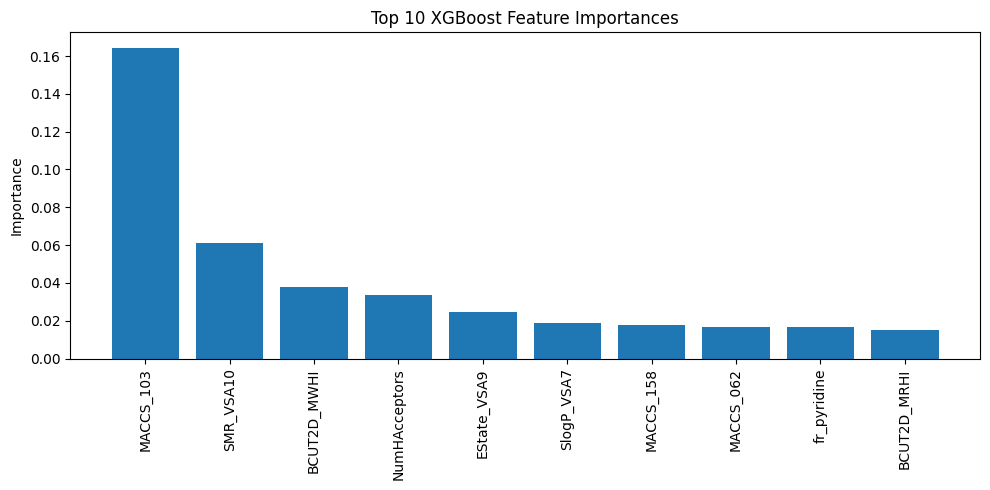

In [17]:
# Extract top 10 features by importance from XGBoost
importances_xgb = grid_search_xgb.best_estimator_.feature_importances_
feature_names = X_train.columns if hasattr(X_train, "columns") else [f"feat_{i}" for i in range(X_train.shape[1])]
top_idx_xgb = np.argsort(importances_xgb)[-10:][::-1]
top_features_xgb = [(feature_names[i], importances_xgb[i]) for i in top_idx_xgb]
print("Top 10 XGBoost features (by importance):")
for name, val in top_features_xgb:
    print(f"{name}: {val:.4f}")

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances_xgb[top_idx_xgb])
plt.xticks(range(10), [feature_names[i] for i in top_idx_xgb], rotation=90)
plt.title("Top 10 XGBoost Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()